In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import pickle
import os
from datetime import datetime
from typing import Dict, List, Tuple
import unicodedata
# Define document types
document_types = {
    'QUYET_DINH': 'Quyết định',
    'NGHI_QUYET': 'Nghị quyết',
    'CONG_DIEN': 'Công điện',
    'CHI_THI': 'Chỉ thị',
    'THONG_BAO': 'Thông báo',
    'NGHI_DINH': 'Nghị định',
    'THONG_TU': 'Thông tư',
    'HUONG_DAN': 'Hướng dẫn',
    'KET_LUAN': 'Kết luận',
    'KE_HOACH': 'Kế hoạch',
    'QUY_DINH': 'Quy định'
}

# Global variables
is_trained = False
pipeline = None
def preprocess_text(text: str) -> str:
    """Tiền xử lý văn bản tiếng Việt"""
    # Chuẩn hóa Unicode
    text = unicodedata.normalize('NFC', text)
    
    # Loại bỏ ký tự đặc biệt, giữ lại dấu câu cơ bản
    text = re.sub(r'[^\w\s\.\,\;\:\!\?\-\(\)]', ' ', text)
    
    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text)
    
    # Chuyển về chữ thường
    text = text.lower().strip()
    
    return text

In [2]:
def extract_document_metadata(content: str) -> Dict:
    """Trích xuất metadata từ văn bản"""
    metadata = {
        'document_number': None,
        'date_issued': None,
        'issuing_authority': None,
        'title': None,
        'document_type': None
    }
    
    # Trích xuất số văn bản
    number_pattern = r'số:?\s*(\d+[\/\-\w]*)'
    number_match = re.search(number_pattern, content, re.IGNORECASE)
    if number_match:
        metadata['document_number'] = number_match.group(1)
    
    # Trích xuất ngày ban hành
    date_patterns = [
        r'ngày\s+(\d{1,2})\s+tháng\s+(\d{1,2})\s+năm\s+(\d{4})',
        r'(\d{1,2})\/(\d{1,2})\/(\d{4})',
        r'(\d{1,2})\-(\d{1,2})\-(\d{4})'
    ]
    for pattern in date_patterns:
        date_match = re.search(pattern, content, re.IGNORECASE)
        if date_match:
            day, month, year = date_match.groups()
            metadata['date_issued'] = f"{day}/{month}/{year}"
            break
    
    # Trích xuất cơ quan ban hành
    authority_patterns = [
        r'(bộ\s+\w+)',
        r'(thủ\s+tướng\s+chính\s+phủ)',
        r'(ban\s+chấp\s+hành\s+trung\s+ương)',
        r'(ủy\s+ban\s+nhân\s+dân)'
    ]
    for pattern in authority_patterns:
        auth_match = re.search(pattern, content, re.IGNORECASE)
        if auth_match:
            metadata['issuing_authority'] = auth_match.group(1).title()
            break
    
    # Trích xuất tiêu đề
    title_match = re.search(r'tiêu\s+đề:\s*(.+?)(?:\n|={3,})', content, re.IGNORECASE | re.DOTALL)
    if title_match:
        metadata['title'] = title_match.group(1).strip()
    
    return metadata

In [3]:
import re
from typing import List, Dict

def detect_document_type(content: str) -> str:
    content_lower = content.lower()
    keywords = {
        "nghị định": "NGHI_DINH",
        "thông tư": "THONG_TU",
        "quyết định": "QUYET_DINH",
        "nghị quyết": "NGHI_QUYET",
        "hướng dẫn": "HUONG_DAN",
        "kết luận": "KET_LUAN",
        "kế hoạch": "KE_HOACH",
        "công điện": "CONG_DIEN",
        "chỉ thị": "CHI_THI",
        "quy định": "QUY_DINH",
        "thông báo": "THONG_BAO"
    }
    
    min_pos = float('inf')
    detected_type = "KHAC"
    
    for keyword, doc_type in keywords.items():
        pos = content_lower.find(keyword)
        if pos != -1 and pos < min_pos:
            min_pos = pos
            detected_type = doc_type
    
    return detected_type

def extract_rules_and_regulations(content: str) -> Dict:
    rules = []
    
    # Pattern điều luật: Chỉ lấy "Điều X." (có dấu chấm)
    article_pattern = r'(Điều\s+\d+\.\s+)(.*?)(?=(?:\nĐiều\s+\d+\.\s+|\Z))'
    
    articles = re.finditer(article_pattern, content, re.IGNORECASE | re.DOTALL)
    for idx, article in enumerate(articles, 1):
        article_title = article.group(1).strip()
        article_content = article.group(2).strip()
        rule = {
            'type': 'article',
            'number': str(idx),
            'content': article_content,
            'clauses': []
        }
        clause_pattern = r'(\d+)\.\s+([^\n]+?)(?=\n\d+\.|\Z)'
        clauses = re.finditer(clause_pattern, article_content, re.MULTILINE)
        for clause in clauses:
            clause_num = clause.group(1)
            clause_content = clause.group(2).strip()
            rule['clauses'].append({
                'number': clause_num,
                'content': clause_content
            })
        rules.append(rule)
    
    obligation_patterns = [
        r'phải\s+([^\.]+)',
        r'bắt\s+buộc\s+([^\.]+)',
        r'yêu\s+cầu\s+([^\.]+)',
        r'quy\s+định\s+([^\.]+)'
    ]
    
    obligations = []
    for pattern in obligation_patterns:
        matches = re.finditer(pattern, content, re.IGNORECASE)
        for match in matches:
            obligations.append({
                'type': 'obligation',
                'content': match.group(1).strip()
            })
    
    timeline_pattern = r'(?:trước\s+ngày|chậm\s+nhất\s+vào\s+ngày|từ\s+ngày)\s+(\d{1,2}\s+tháng\s+\d{1,2}\s+năm\s+\d{4})'
    timelines = []
    timeline_matches = re.finditer(timeline_pattern, content, re.IGNORECASE)
    for match in timeline_matches:
        timelines.append({
            'type': 'timeline',
            'deadline': match.group(1).strip(),
            'context': match.group(0)
        })
    
    # Trích xuất cơ quan ban hành đầy đủ
    issuing_agency_pattern = r'(?:Theo\s+đề\s+nghị\s+của\s+(Bộ trưởng\s+Bộ\s+[^\n;]+?)[\n;]|Bộ trưởng\s+Bộ\s+[^\n;]+?|Chính phủ|Ủy ban nhân dân|Ban\s+chấp\s+hành\s+trung\s+ương)'
    issuing_agency_match = re.search(issuing_agency_pattern, content, re.IGNORECASE)
    issuing_agency = issuing_agency_match.group(1).strip() if issuing_agency_match and issuing_agency_match.group(1) else issuing_agency_match.group(0).strip() if issuing_agency_match else "Không xác định"
    
    # Trích xuất số văn bản và ngày ban hành
    doc_number_pattern = r'(?:\d+/\d{4}/\d+/\w+|\d+/\d{4}/\w+)'
    doc_number_match = re.search(doc_number_pattern, content)
    doc_number = doc_number_match.group(0) if doc_number_match else "Không xác định"
    
    date_pattern = r'\d{1,2}/\d{1,2}/\d{4}'
    date_match = re.search(date_pattern, content)
    issue_date = date_match.group(0) if date_match else "Không xác định"
    
    return {
        'document_type': detect_document_type(content),
        'document_number': doc_number,
        'issue_date': issue_date,
        'issuing_agency': issuing_agency,
        'articles': rules,
        'obligations': obligations,
        'timelines': timelines
    }


In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
def prepare_training_data(folder_path: str, csv_output: str = 'document_labels.csv') -> Tuple[List[str], List[str]]:
    """Chuẩn bị dữ liệu training từ folder chứa các file txt và lưu nhãn vào CSV"""
    texts = []
    labels = []
    file_names = []
    
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.txt'):
            file_path = os.path.join(folder_path, file_name)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    content = f.read()
                
                processed_text = preprocess_text(content)
                texts.append(processed_text)
                
                doc_type = detect_document_type(content)
                labels.append(doc_type)
                file_names.append(file_name)
                
            except Exception as e:
                print(f"Lỗi xử lý file {file_path}: {e}")
                continue
    
    # Save to CSV
    if texts and labels:
        df = pd.DataFrame({
            'file_name': file_names,
            'document_type': labels,
            'processed_text': texts
        })
        df.to_csv(csv_output, index=False, encoding='utf-8')
        print(f"Đã lưu nhãn vào {csv_output}")
    
    return texts, labels

    

In [5]:
def train_classifier(texts: List[str], labels: List[str]):
    """Huấn luyện mô hình phân loại"""
    global pipeline, is_trained, y_test, y_pred
    
    # Check class counts to handle stratification
    class_counts = pd.Series(labels).value_counts()
    use_stratify = all(count >= 2 for count in class_counts)
    if not use_stratify:
        print("Cảnh báo: Một số lớp có ít hơn 2 mẫu, không sử dụng stratify trong train_test_split.")
    
    # Tách dữ liệu train/test
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels if use_stratify else None
    )
    
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 3),
            stop_words=None,
            min_df=2,
            max_df=0.8
        )),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        ))
    ])
    
    print("Đang huấn luyện mô hình...")
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    print("\nKết quả đánh giá mô hình:")
    print(classification_report(y_test, y_pred))
    
    is_trained = True
    print("Hoàn thành huấn luyện mô hình!")
    
    
    # Kiểm tra xem y_test và y_pred đã được gán chưa
    if y_test is not None and y_pred is not None:
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
    else:
        print("Chưa có dữ liệu y_test hoặc y_pred. Hãy chắc chắn đã gọi train_classifier(...) trước.")
    # Tạo báo cáo dạng dict
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    
    # Lọc các lớp (không lấy avg)
    df_class = df_report.iloc[:-3, :][["precision", "recall", "f1-score", "support"]]

In [6]:
def predict_document_type(text: str) -> Tuple[str, float]:
    """Dự đoán loại văn bản"""
    global pipeline, is_trained
    if not is_trained:
        raise ValueError("Mô hình chưa được huấn luyện!")
    processed_text = preprocess_text(text)
    prediction = pipeline.predict([processed_text])[0]
    # Kiểm tra classifier bên trong pipeline
    classifier = pipeline
    if hasattr(pipeline, 'named_steps') and 'classifier' in pipeline.named_steps:
        classifier = pipeline.named_steps['classifier']
    probability = None
    if hasattr(classifier, 'predict_proba'):
        probability = max(pipeline.predict_proba([processed_text])[0])
    elif hasattr(classifier, 'decision_function'):
        decision = pipeline.decision_function([processed_text])
        import numpy as np
        if hasattr(decision, "__len__") and len(decision.shape) > 1 and decision.shape[1] > 1:
            val = max(decision[0])
            min_val = min(decision[0])
            max_val = max(decision[0])
            probability = (val - min_val) / (max_val - min_val) if max_val != min_val else 1.0
        else:
            val = abs(float(decision[0]))
            probability = min(val / 10, 1.0)
    else:
        probability = None
    return prediction, probability

In [7]:
def save_model(filepath: str):
    """Lưu mô hình đã huấn luyện"""
    global pipeline, is_trained, document_types
    if not is_trained:
        raise ValueError("Mô hình chưa được huấn luyện!")
    
    model_data = {
        'pipeline': pipeline,
        'document_types': document_types,
        'is_trained': is_trained
    }
    
    with open(filepath, 'wb') as f:
        pickle.dump(model_data, f)
    print(f"Đã lưu mô hình vào {filepath}")

In [8]:
def load_model(filepath: str):
    """Tải mô hình đã lưu"""
    global pipeline, is_trained, document_types
    with open(filepath, 'rb') as f:
        model_data = pickle.load(f)
    
    pipeline = model_data['pipeline']
    document_types = model_data['document_types']
    is_trained = model_data['is_trained']
    print(f"Đã tải mô hình từ {filepath}")

In [9]:
def analyze_document(content: str) -> Dict:
    """Phân tích toàn diện một văn bản"""
    global is_trained
    result = {
        'metadata': extract_document_metadata(content),
        'document_type_detected': detect_document_type(content),
        'rules_extracted': extract_rules_and_regulations(content)
    }
    
    if is_trained:
        predicted_type, confidence = predict_document_type(content)
        result['document_type_predicted'] = predicted_type
        result['prediction_confidence'] = confidence
    
    return result

# Đường dẫn đến folder chứa các file .txt
folder_path = "data"  # Thay đổi đường dẫn này

# Chuẩn bị dữ liệu training và lưu vào CSV
print("Đang chuẩn bị dữ liệu training...")
texts, labels = prepare_training_data(folder_path, csv_output='document_labels.csv')

# Huấn luyện mô hình nếu có dữ liệu
if texts and labels:
    train_classifier(texts, labels)
    
    # Lưu mô hình
    save_model('legal_document_classifier.pkl')

Đang chuẩn bị dữ liệu training...
Đã lưu nhãn vào document_labels.csv
Đang huấn luyện mô hình...
Đã lưu nhãn vào document_labels.csv
Đang huấn luyện mô hình...

Kết quả đánh giá mô hình:
              precision    recall  f1-score   support

     CHI_THI       0.94      0.77      0.85        22
   CONG_DIEN       0.97      1.00      0.99        33
   HUONG_DAN       0.85      0.73      0.79        15
    KET_LUAN       0.67      0.80      0.73         5
    KE_HOACH       0.91      1.00      0.95        40
   NGHI_DINH       1.00      1.00      1.00        20
  NGHI_QUYET       1.00      1.00      1.00       103
  QUYET_DINH       1.00      1.00      1.00       365
    QUY_DINH       0.80      1.00      0.89         4
   THONG_BAO       1.00      0.94      0.97        36
    THONG_TU       1.00      1.00      1.00        31

    accuracy                           0.98       674
   macro avg       0.92      0.93      0.92       674
weighted avg       0.98      0.98      0.98       674



In [10]:

# # Demo phân tích văn bản
# with open("sample_text.txt", "r", encoding="utf-8") as f:
#     content = f.read()

# metadata = extract_document_metadata(content)
# document_type = detect_document_type(content)
# rule_data = extract_rules_and_regulations(content)

# print("=== KẾT QUẢ PHÂN TÍCH VĂN BẢN ===")
# print(f"Loại văn bản: {document_types.get(document_type, 'Không xác định')}")
# print(f"Số văn bản: {metadata.get('document_number', 'Không rõ')}")
# print(f"Ngày ban hành: {metadata.get('date_issued', 'Không rõ')}")
# print(f"Cơ quan ban hành: {rule_data.get('issuing_agency', 'Không rõ')}")
# print()
# print(f"Số điều được trích xuất: {len(rule_data['articles'])}")
# print(f"Số nghĩa vụ được trích xuất: {len(rule_data['obligations'])}")
# print(f"Số thời hạn được trích xuất: {len(rule_data['timelines'])}")


SVM


In [11]:
# Import LinearSVC
from sklearn.svm import LinearSVC

def train_svm(texts: list, labels: list):
    """Huấn luyện và đánh giá mô hình SVM"""
    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import classification_report
    import pandas as pd
    
    # Kiểm tra số lượng mẫu mỗi lớp
    class_counts = pd.Series(labels).value_counts()
    use_stratify = all(count >= 2 for count in class_counts)
    if not use_stratify:
        print("Cảnh báo: Một số lớp có ít hơn 2 mẫu, không sử dụng stratify trong train_test_split.")
    
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels if use_stratify else None
    )
    
    svm_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 3),
            stop_words=None,
            min_df=2,
            max_df=0.8
        )),
        ('classifier', LinearSVC())
    ])
    print("Đang huấn luyện mô hình SVM...")
    svm_pipeline.fit(X_train, y_train)
    y_pred = svm_pipeline.predict(X_test)
    print("\nKết quả đánh giá mô hình SVM:")
    print(classification_report(y_test, y_pred))
    return svm_pipeline

In [12]:
# Huấn luyện và đánh giá mô hình SVM với dữ liệu đã chuẩn bị
if texts and labels:
    svm_model = train_svm(texts, labels)
else:
    print("Chưa có dữ liệu để huấn luyện mô hình SVM.")

Đang huấn luyện mô hình SVM...

Kết quả đánh giá mô hình SVM:
              precision    recall  f1-score   support

     CHI_THI       0.57      0.55      0.56        22
   CONG_DIEN       0.97      0.88      0.92        33
   HUONG_DAN       0.59      0.67      0.62        15
    KET_LUAN       0.67      0.80      0.73         5
    KE_HOACH       0.73      0.75      0.74        40
   NGHI_DINH       0.94      0.80      0.86        20
  NGHI_QUYET       0.98      0.99      0.99       103
  QUYET_DINH       0.95      0.98      0.97       365
    QUY_DINH       0.67      0.50      0.57         4
   THONG_BAO       0.91      0.81      0.85        36
    THONG_TU       0.92      0.77      0.84        31

    accuracy                           0.92       674
   macro avg       0.81      0.77      0.79       674
weighted avg       0.92      0.92      0.91       674


Kết quả đánh giá mô hình SVM:
              precision    recall  f1-score   support

     CHI_THI       0.57      0.55      

In [13]:
# Lưu lại mô hình SVM đã huấn luyện
import pickle

def save_svm_model(model, filepath: str):
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"Đã lưu mô hình SVM vào {filepath}")

# Ví dụ lưu mô hình
if 'svm_model' in globals():
    save_svm_model(svm_model, 'svm_classifier.pkl')
else:
    print("Chưa có mô hình SVM để lưu.")

Đã lưu mô hình SVM vào svm_classifier.pkl


Naive_Bayes

In [14]:
# Import MultinomialNB
from sklearn.naive_bayes import MultinomialNB

def train_naive_bayes(texts: list, labels: list):
    """Huấn luyện và đánh giá mô hình Naive Bayes"""
    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import classification_report
    import pandas as pd
    
    # Kiểm tra số lượng mẫu mỗi lớp
    class_counts = pd.Series(labels).value_counts()
    use_stratify = all(count >= 2 for count in class_counts)
    if not use_stratify:
        print("Cảnh báo: Một số lớp có ít hơn 2 mẫu, không sử dụng stratify trong train_test_split.")
    
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels if use_stratify else None
    )
    
    nb_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 3),
            stop_words=None,
            min_df=2,
            max_df=0.8
        )),
        ('classifier', MultinomialNB())
    ])
    print("Đang huấn luyện mô hình Naive Bayes...")
    nb_pipeline.fit(X_train, y_train)
    y_pred = nb_pipeline.predict(X_test)
    print("\nKết quả đánh giá mô hình Naive Bayes:")
    print(classification_report(y_test, y_pred))
    return nb_pipeline

In [15]:
# Huấn luyện và đánh giá mô hình Naive Bayes với dữ liệu đã chuẩn bị
if texts and labels:
    nb_model = train_naive_bayes(texts, labels)
else:
    print("Chưa có dữ liệu để huấn luyện mô hình Naive Bayes.")

Đang huấn luyện mô hình Naive Bayes...

Kết quả đánh giá mô hình Naive Bayes:
              precision    recall  f1-score   support

     CHI_THI       0.80      0.18      0.30        22
   CONG_DIEN       0.71      0.82      0.76        33
   HUONG_DAN       0.00      0.00      0.00        15
    KET_LUAN       0.00      0.00      0.00         5
    KE_HOACH       0.46      0.93      0.62        40
   NGHI_DINH       0.00      0.00      0.00        20
  NGHI_QUYET       0.80      0.95      0.87       103
  QUYET_DINH       0.92      0.91      0.92       365
    QUY_DINH       0.00      0.00      0.00         4
   THONG_BAO       0.76      0.78      0.77        36
    THONG_TU       0.66      0.61      0.63        31

    accuracy                           0.81       674
   macro avg       0.46      0.47      0.44       674
weighted avg       0.78      0.81      0.78       674


Kết quả đánh giá mô hình Naive Bayes:
              precision    recall  f1-score   support

     CHI_THI   

c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# Lưu lại mô hình Naive Bayes đã huấn luyện
import pickle

def save_naive_bayes_model(model, filepath: str):
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"Đã lưu mô hình Naive Bayes vào {filepath}")

# Ví dụ lưu mô hình
if 'nb_model' in globals():
    save_naive_bayes_model(nb_model, 'naive_bayes_classifier.pkl')
else:
    print("Chưa có mô hình Naive Bayes để lưu.")

Đã lưu mô hình Naive Bayes vào naive_bayes_classifier.pkl


MLP

In [17]:
# Huấn luyện và lưu mô hình MLP (Mạng nơ-ron)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle

def train_mlp(texts, labels):
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)
    mlp_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 3), min_df=2, max_df=0.8)),
        ('classifier', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100, random_state=42))
    ])
    print("Đang huấn luyện mô hình MLP...")
    mlp_pipeline.fit(X_train, y_train)
    y_pred = mlp_pipeline.predict(X_test)
    print("\nKết quả đánh giá mô hình MLP:")
    print(classification_report(y_test, y_pred))
    return mlp_pipeline

if texts and labels:
    mlp_model = train_mlp(texts, labels)
    with open('mlp_classifier.pkl', 'wb') as f:
        pickle.dump(mlp_model, f)
    print("Đã lưu mô hình MLP vào mlp_classifier.pkl")
else:
    print("Chưa có dữ liệu để huấn luyện mô hình MLP.")

Đang huấn luyện mô hình MLP...

Kết quả đánh giá mô hình MLP:
              precision    recall  f1-score   support

     CHI_THI       0.65      0.65      0.65        20
   CONG_DIEN       0.88      0.86      0.87        43
   HUONG_DAN       0.64      0.64      0.64        14
    KET_LUAN       0.00      0.00      0.00         0
    KE_HOACH       0.86      0.82      0.84        44
   NGHI_DINH       0.91      0.72      0.81        29
  NGHI_QUYET       0.95      0.96      0.95        96
  QUYET_DINH       0.96      0.98      0.97       363
    QUY_DINH       1.00      1.00      1.00         3
   THONG_BAO       1.00      0.90      0.95        31
    THONG_TU       0.85      0.90      0.88        31

    accuracy                           0.92       674
   macro avg       0.79      0.77      0.78       674
weighted avg       0.93      0.92      0.92       674

Đã lưu mô hình MLP vào mlp_classifier.pkl

Kết quả đánh giá mô hình MLP:
              precision    recall  f1-score   suppor

c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


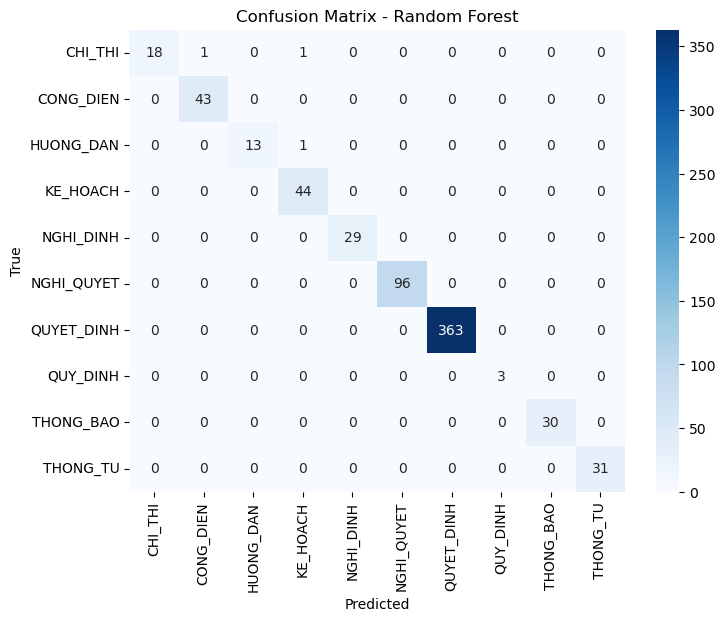

Classification Report - Random Forest:
              precision    recall  f1-score   support

     CHI_THI       1.00      0.90      0.95        20
   CONG_DIEN       0.98      1.00      0.99        43
   HUONG_DAN       1.00      0.93      0.96        14
    KET_LUAN       0.00      0.00      0.00         0
    KE_HOACH       0.96      1.00      0.98        44
   NGHI_DINH       1.00      1.00      1.00        29
  NGHI_QUYET       1.00      1.00      1.00        96
  QUYET_DINH       1.00      1.00      1.00       363
    QUY_DINH       1.00      1.00      1.00         3
   THONG_BAO       1.00      0.97      0.98        31
    THONG_TU       1.00      1.00      1.00        31

    accuracy                           0.99       674
   macro avg       0.90      0.89      0.90       674
weighted avg       1.00      0.99      0.99       674



c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


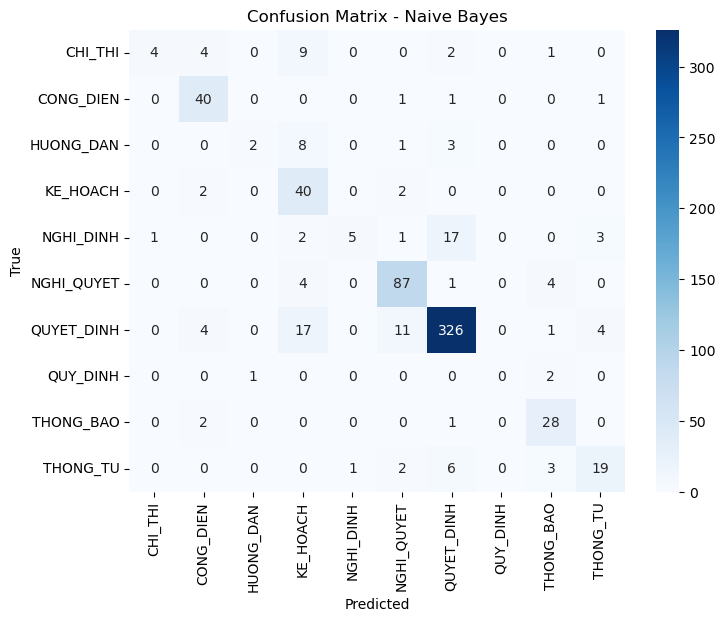

Classification Report - Naive Bayes:
              precision    recall  f1-score   support

     CHI_THI       0.80      0.20      0.32        20
   CONG_DIEN       0.77      0.93      0.84        43
   HUONG_DAN       0.67      0.14      0.24        14
    KE_HOACH       0.50      0.91      0.65        44
   NGHI_DINH       0.83      0.17      0.29        29
  NGHI_QUYET       0.83      0.91      0.87        96
  QUYET_DINH       0.91      0.90      0.91       363
    QUY_DINH       0.00      0.00      0.00         3
   THONG_BAO       0.72      0.90      0.80        31
    THONG_TU       0.70      0.61      0.66        31

    accuracy                           0.82       674
   macro avg       0.67      0.57      0.56       674
weighted avg       0.83      0.82      0.80       674



c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


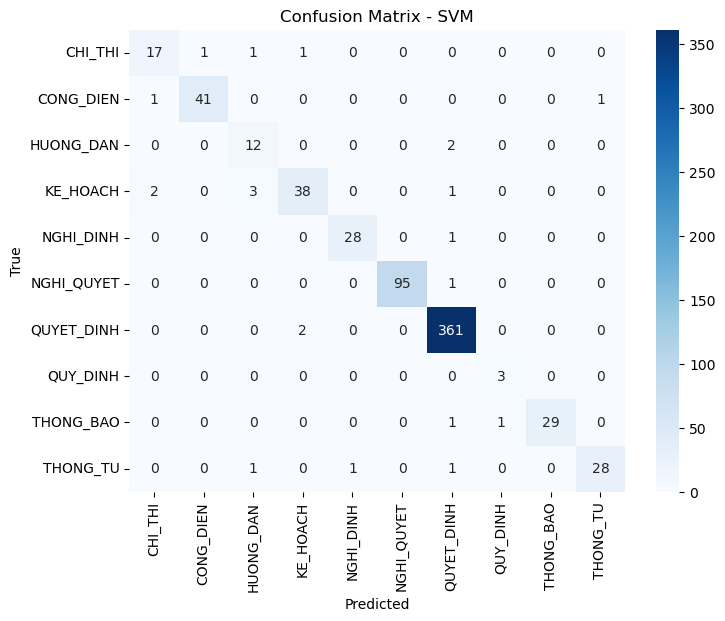

Classification Report - SVM:
              precision    recall  f1-score   support

     CHI_THI       0.85      0.85      0.85        20
   CONG_DIEN       0.98      0.95      0.96        43
   HUONG_DAN       0.71      0.86      0.77        14
    KE_HOACH       0.93      0.86      0.89        44
   NGHI_DINH       0.97      0.97      0.97        29
  NGHI_QUYET       1.00      0.99      0.99        96
  QUYET_DINH       0.98      0.99      0.99       363
    QUY_DINH       0.75      1.00      0.86         3
   THONG_BAO       1.00      0.94      0.97        31
    THONG_TU       0.97      0.90      0.93        31

    accuracy                           0.97       674
   macro avg       0.91      0.93      0.92       674
weighted avg       0.97      0.97      0.97       674



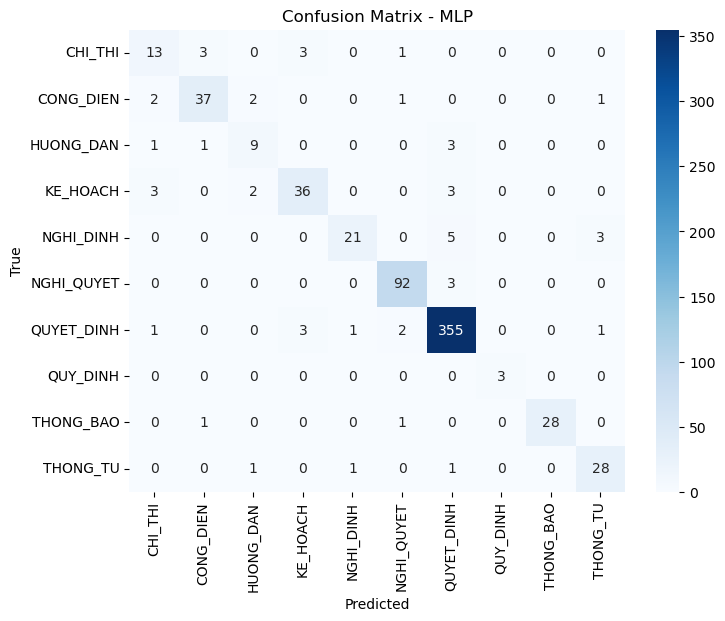

Classification Report - MLP:
              precision    recall  f1-score   support

     CHI_THI       0.65      0.65      0.65        20
   CONG_DIEN       0.88      0.86      0.87        43
   HUONG_DAN       0.64      0.64      0.64        14
    KET_LUAN       0.00      0.00      0.00         0
    KE_HOACH       0.86      0.82      0.84        44
   NGHI_DINH       0.91      0.72      0.81        29
  NGHI_QUYET       0.95      0.96      0.95        96
  QUYET_DINH       0.96      0.98      0.97       363
    QUY_DINH       1.00      1.00      1.00         3
   THONG_BAO       1.00      0.90      0.95        31
    THONG_TU       0.85      0.90      0.88        31

    accuracy                           0.92       674
   macro avg       0.79      0.77      0.78       674
weighted avg       0.93      0.92      0.92       674



c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dloc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_evaluation(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    print(f"Classification Report - {model_name}:")
    print(classification_report(y_test, y_pred))

# Đánh giá từng mô hình
from sklearn.model_selection import train_test_split

# Chuẩn bị tập test chung
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Random Forest
plot_evaluation(pipeline, X_test, y_test, model_name="Random Forest")

# Naive Bayes
if 'nb_model' in globals():
    plot_evaluation(nb_model, X_test, y_test, model_name="Naive Bayes")

# SVM
if 'svm_model' in globals():
    plot_evaluation(svm_model, X_test, y_test, model_name="SVM")

# MLP
if 'mlp_model' in globals():
    plot_evaluation(mlp_model, X_test, y_test, model_name="MLP")

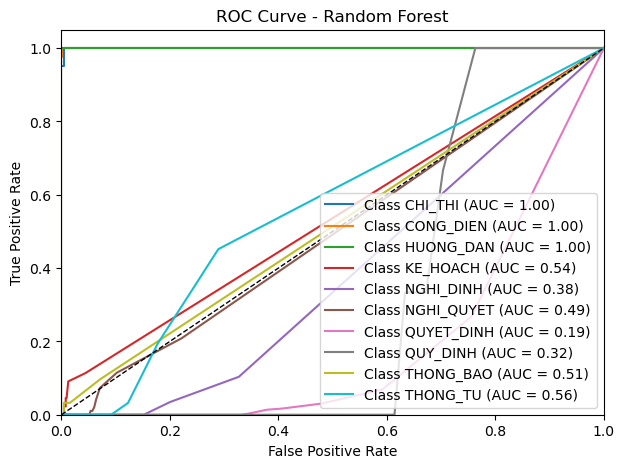

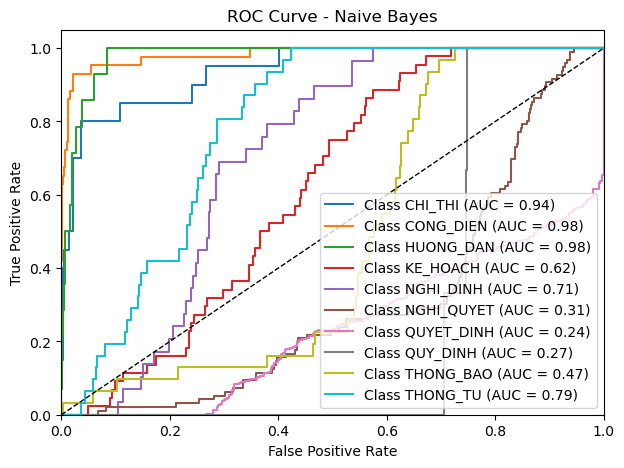

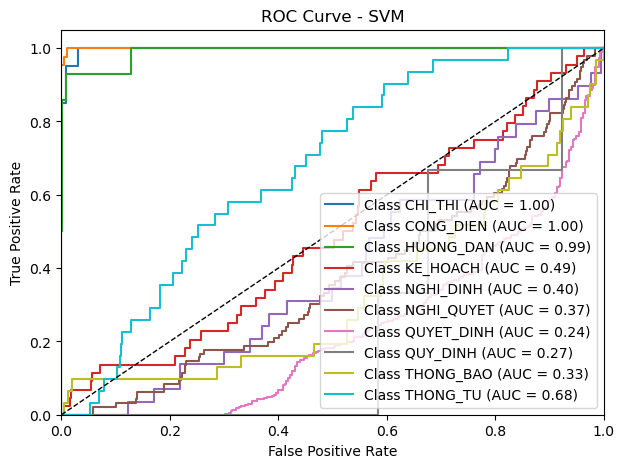

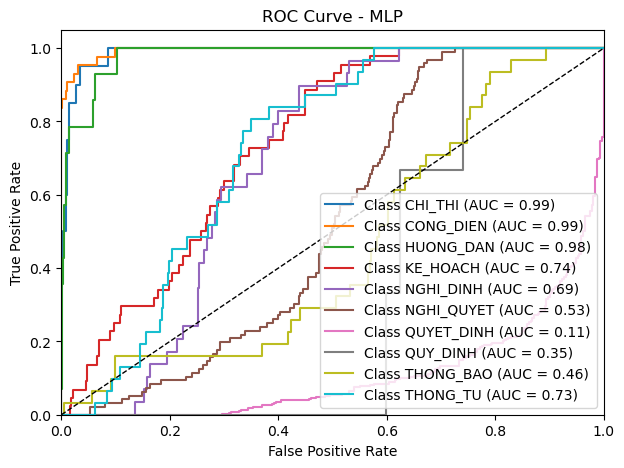

In [23]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np

def plot_roc(model, X_test, y_test, model_name="Model"):
    # Binarize labels for multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    # Dự đoán xác suất hoặc decision_function
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        # Nếu là nhị phân, reshape về (n_samples, 1)
        if len(y_score.shape) == 1:
            y_score = y_score.reshape(-1, 1)
    else:
        print(f"{model_name} không hỗ trợ ROC curve.")
        return

    n_classes = y_test_bin.shape[1] if len(y_test_bin.shape) > 1 else 1
    plt.figure(figsize=(7, 5))

    if n_classes == 1:
        # Nhị phân
        if y_score.shape[1] == 1:
            y_score = np.hstack([1 - y_score, y_score])
        fpr, tpr, _ = roc_curve(y_test_bin, y_score[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    else:
        # Đa lớp
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {lb.classes_[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

# Vẽ ROC cho từng mô hình
plot_roc(pipeline, X_test, y_test, model_name="Random Forest")

if 'nb_model' in globals():
    plot_roc(nb_model, X_test, y_test, model_name="Naive Bayes")

if 'svm_model' in globals():
    plot_roc(svm_model, X_test, y_test, model_name="SVM")

if 'mlp_model' in globals():
    plot_roc(mlp_model, X_test, y_test, model_name="MLP")


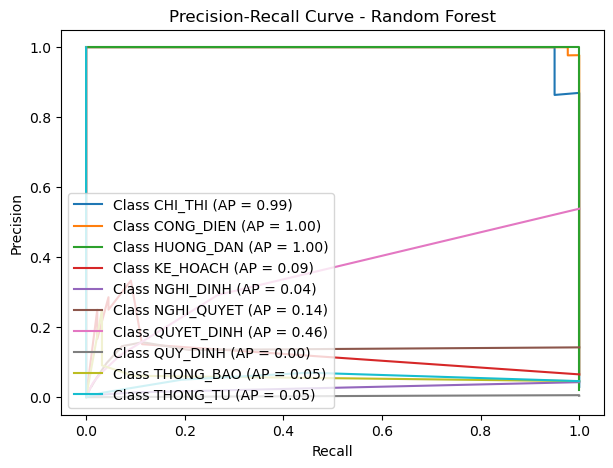

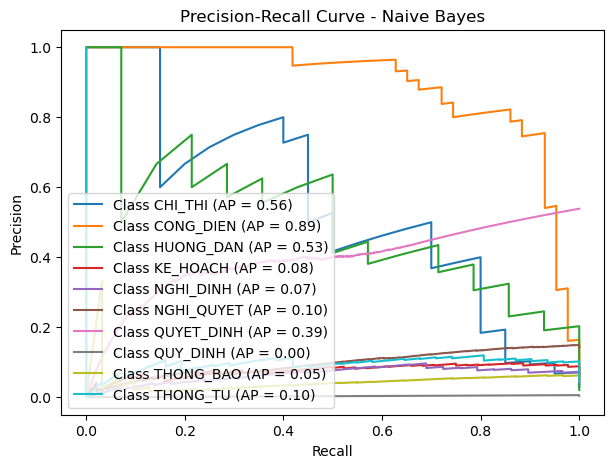

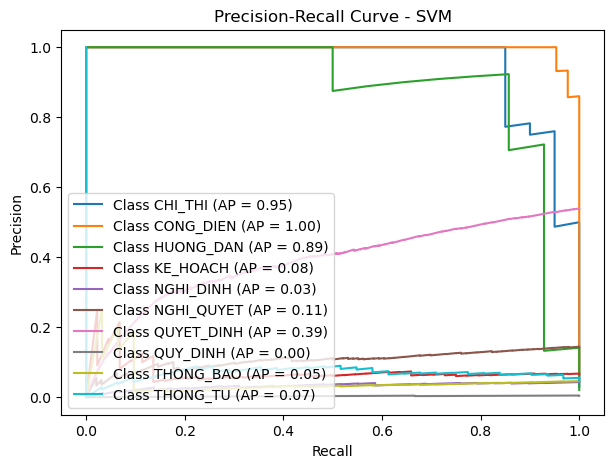

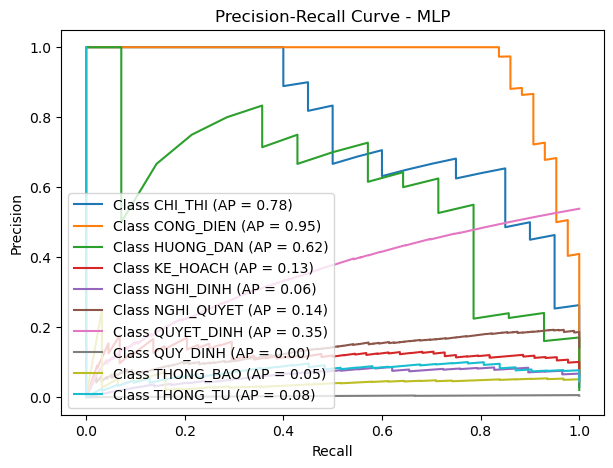

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall(model, X_test, y_test, model_name="Model"):
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        if len(y_score.shape) == 1:
            y_score = y_score.reshape(-1, 1)
    else:
        print(f"{model_name} không hỗ trợ Precision-Recall curve.")
        return
    n_classes = y_test_bin.shape[1] if len(y_test_bin.shape) > 1 else 1
    plt.figure(figsize=(7,5))
    if n_classes == 1:
        # Nhị phân
        if y_score.shape[1] == 1:
            y_score = np.hstack([1-y_score, y_score])
        precision, recall, _ = precision_recall_curve(y_test_bin, y_score[:,1])
        ap = average_precision_score(y_test_bin, y_score[:,1])
        plt.plot(recall, precision, label=f'AP = {ap:.2f}')
    else:
        # Đa lớp
        for i in range(n_classes):
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
            ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
            plt.plot(recall, precision, label=f'Class {lb.classes_[i]} (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc="lower left")
    plt.show()

# Vẽ Precision-Recall cho từng mô hình
plot_precision_recall(pipeline, X_test, y_test, model_name="Random Forest")
if 'nb_model' in globals():
    plot_precision_recall(nb_model, X_test, y_test, model_name="Naive Bayes")
if 'svm_model' in globals():
    plot_precision_recall(svm_model, X_test, y_test, model_name="SVM")
if 'mlp_model' in globals():
    plot_precision_recall(mlp_model, X_test, y_test, model_name="MLP")

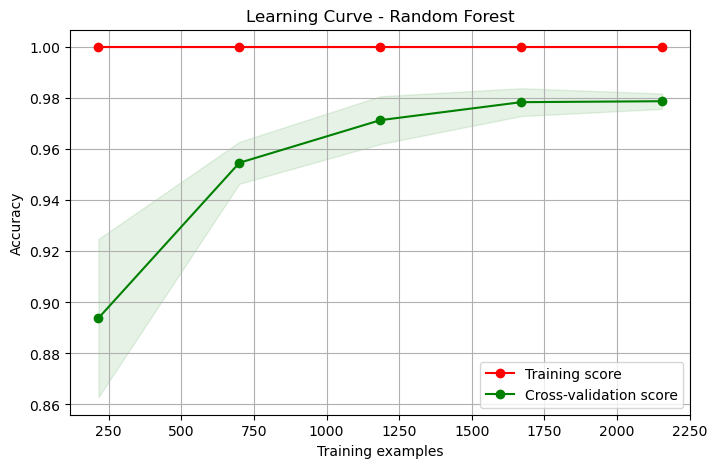

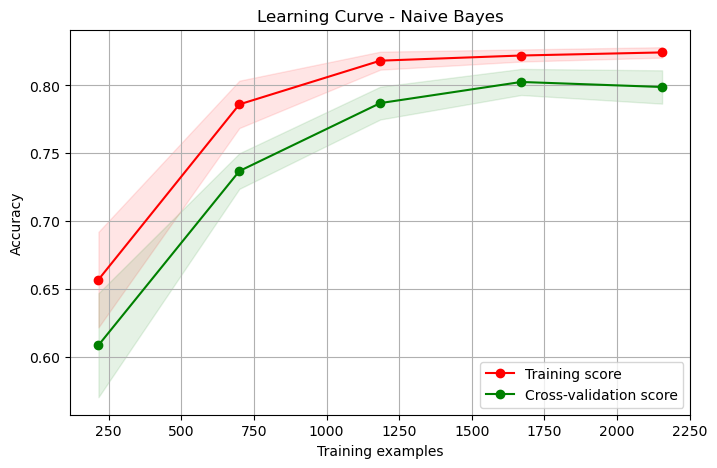

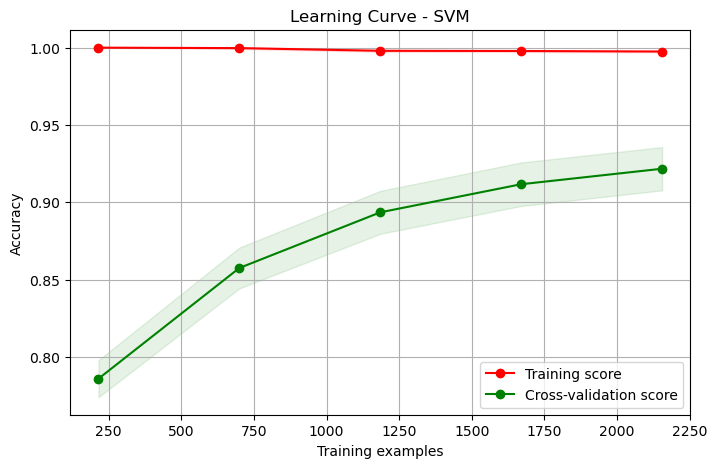

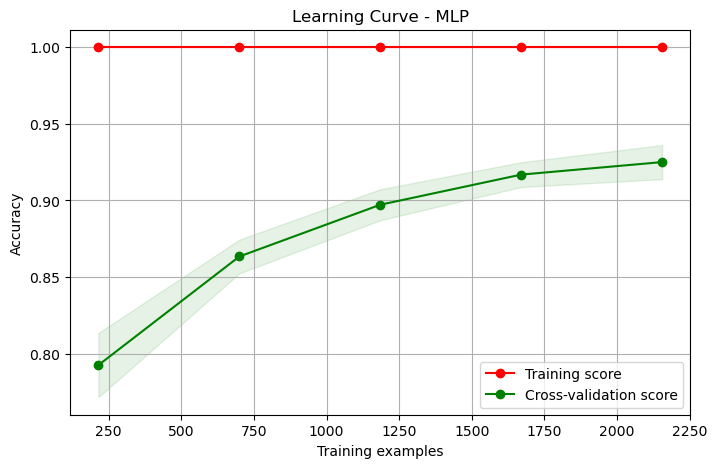

In [21]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(estimator, X, y, model_name="Model", cv=5, scoring="accuracy"):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

# Chuẩn bị lại dữ liệu đầu vào cho learning curve
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Random Forest
if 'pipeline' in globals():
    plot_learning_curve(pipeline, X_train, y_train, model_name="Random Forest")
# Naive Bayes
if 'nb_model' in globals():
    plot_learning_curve(nb_model, X_train, y_train, model_name="Naive Bayes")
# SVM
if 'svm_model' in globals():
    plot_learning_curve(svm_model, X_train, y_train, model_name="SVM")
# MLP
if 'mlp_model' in globals():
    plot_learning_curve(mlp_model, X_train, y_train, model_name="MLP")
